In [1]:
# -----------------------------------------------------------------------------------------
# CELL 1: LOAD AND VALIDATE US-DOMESTIC METRO DATA
# -----------------------------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style for clean visuals
sns.set_theme(style="whitegrid")
pd.options.display.max_columns = None

# 1. Path to the new Metro-mapped US Domestic data
METRO_PATH = "gs://agntworks-data-dev/wheelsup/processed/wingx/lj_smid_us_revenue_clean_24_25_metro.parquet"

# 2. Load the dataset
print("🚀 Loading US-Domestic Metro mission data...")
df = pd.read_parquet(METRO_PATH)

# 3. Terminology Standardization
# If the pipeline left 'FromCluster' or 'ToCluster', we rename them here to 'Metro'
# to ensure the entire notebook follows the new naming convention.
rename_map = {
    'FromCluster': 'FromMetro',
    'ToCluster': 'ToMetro'
}
df = df.rename(columns=rename_map)

# 4. Feature Integrity Check
# Ensure FlightDate_ET is datetime and extract TOD/DOW if missing
df['FlightDate_ET'] = pd.to_datetime(df['FlightDate_ET'])

if 'hour' not in df.columns:
    df['hour'] = df['FlightDate_ET'].dt.hour

# We use 'day_name' for plotting labels
df['day_name'] = df['FlightDate_ET'].dt.day_name()
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['day_name'] = pd.Categorical(df['day_name'], categories=days, ordered=True)

# --- VALIDATION ---
print(f"✅ Data Loaded: {len(df):,}")
print(f"✅ US-Domestic Check: {df['FromAirport'].str.startswith('K').all()} (All starts with K)")
print(f"✅ Terminology Check: {'FromMetro' in df.columns} (Metro columns present)")

display(df[['FlightDate_ET', 'aircraft_segment', 'FromAirport', 'FromMetro', 'ToAirport', 'ToMetro']].head(5))

🚀 Loading US-Domestic Metro mission data...
✅ Data Loaded: 2,140,706
✅ US-Domestic Check: True (All starts with K)
✅ Terminology Check: True (Metro columns present)


,FlightDate_ET,aircraft_segment,FromAirport,FromMetro,ToAirport,ToMetro
0,2024-03-10 14:37:00-04:00,Super Midsize Jet,KTEX,Denver,KBJC,Denver
1,2024-03-16 18:58:00-04:00,Super Midsize Jet,KJAC,Denver,KSDL,Phoenix Valley
2,2024-03-01 17:32:00-05:00,Super Midsize Jet,KORL,North Florida,KCHO,DMV
3,2024-03-20 12:09:00-04:00,Super Midsize Jet,KFCM,Minneapolis,KSDL,Phoenix Valley
4,2024-03-22 14:12:00-04:00,Super Midsize Jet,KSNA,LA Basin,KSLC,Denver


In [2]:
# -----------------------------------------------------------------------------------------
# CELL 1.5: AIRCRAFT MODEL AUDIT
# LOGIC: Identify all distinct models in the LJ segment to verify filter strings.
# -----------------------------------------------------------------------------------------

# 1. Filter the master dataframe for Light Jets
df_smid_models = df[df['aircraft_segment'] == 'Super Midsize Jet']

# 2. Get unique models and their mission counts (to identify the big players)
model_audit = df_smid_models['aircraft_model'].value_counts().reset_index()
model_audit.columns = ['wingx_model_name', 'mission_count']

print(f"📋 DISTINCT Super Midsize JET MODELS IN DATASET ({len(model_audit)} found):")
print("-" * 50)
display(model_audit)

📋 DISTINCT Super Midsize JET MODELS IN DATASET (16 found):
--------------------------------------------------


,wingx_model_name,mission_count
0,Citation Latitude,260949
1,Challenger 350,167322
2,Challenger 300,117252
3,no model available,94583
4,Citation Longitude,80138
5,Citation X,76938
6,G280,66994
7,Citation Sovereign,65417
8,Challenger 3500,40079
9,Praetor 600,22396


In [3]:
# -----------------------------------------------------------------------------------------
# CELL 2: PREFERRED FLEET SUPER MIDSIZE JET ANALYSIS
# FILTERING: 
#   1. Segment: SUPER MIDSIZE JET
#   2. Market: US-Domestic (K-to-K), Hours >= 0.5
# -----------------------------------------------------------------------------------------

# 1. Filter the master dataframe
# We calculate the 'shrinkage' by comparing against the total LJ volume (1,084,992)
total_smid_all_models = len(df[df['aircraft_segment'] == 'Super Midsize Jet'])

df_smid_raw = df[df['aircraft_segment'] == 'Super Midsize Jet'].copy()

# 2. Create Corridor Key and Aggregate
df_smid_raw['corridor'] = df_smid_raw['FromMetro'] + " ➔ " + df_smid_raw['ToMetro']
corridor_counts_raw = df_smid_raw['corridor'].value_counts().reset_index()
corridor_counts_raw.columns = ['corridor', 'mission_count']

# 3. Market Share Calculation
total_fleet_missions = len(df_smid_raw)
fleet_retention_pct = (total_fleet_missions / total_smid_all_models) * 100
corridor_counts_raw['pct_of_fleet_market'] = (corridor_counts_raw['mission_count'] / total_fleet_missions) * 100
corridor_counts_raw['cumulative_pct'] = corridor_counts_raw['pct_of_fleet_market'].cumsum()

# --- VALIDATION ---
print(f"📊 PREFERRED FLEET ANALYSIS SUMMARY")
print(f"-------------------------------------------")
print(f"Total smid Missions (All Models):    {total_smid_all_models:,}")
print(f"Total smid Missions (Target Fleet): {total_fleet_missions:,}")
print(f"Fleet Selection Retention:         {fleet_retention_pct:.1f}%")
print(f"Volume Shrinkage:                 {100 - fleet_retention_pct:.1f}%")

print(f"\n📋 TOP 20 CORRIDORS (Selected Fleet - Gross View):")
display(corridor_counts_raw.head(20))

📊 PREFERRED FLEET ANALYSIS SUMMARY
-------------------------------------------
Total smid Missions (All Models):    1,055,714
Total smid Missions (Target Fleet): 1,055,714
Fleet Selection Retention:         100.0%
Volume Shrinkage:                 0.0%

📋 TOP 20 CORRIDORS (Selected Fleet - Gross View):


,corridor,mission_count,pct_of_fleet_market,cumulative_pct
0,LA Basin ➔ LA Basin,19743,1.870109,1.870109
1,LA Basin ➔ Bay Area,17487,1.656415,3.526523
2,Bay Area ➔ LA Basin,17136,1.623167,5.149690
3,Denver ➔ Denver,14499,1.373383,6.523073
4,Boston ➔ New York City,12741,1.206861,7.729934
5,New York City ➔ Boston,12267,1.161962,8.891897
6,South Florida ➔ New York City,12220,1.157510,10.049407
7,New York City ➔ South Florida,12208,1.156374,11.205781
8,Denver ➔ LA Basin,10487,0.993356,12.199137
9,South Florida ➔ North Florida,10458,0.990609,13.189746


In [4]:
# -----------------------------------------------------------------------------------------
# CELL 3: STRUCTURAL FILTERING (INTER-METRO MARKET)
# FILTERING: 
#   1. Segment: Super Midsize Jet Only (Carried from Cell 2)
#   2. Valid Metros: Remove 'OTHER_METRO' from both Origin and Destination
#   3. Inter-Metro Only: Remove flights where FromMetro == ToMetro (Structural Repos)
# -----------------------------------------------------------------------------------------

# 1. Start with the refined fleet from Cell 2
# Filter for Inter-Metro missions between recognized hubs
smid_structural = df_smid_raw[
    (df_smid_raw['FromMetro'] != 'OTHER_METRO') & 
    (df_smid_raw['ToMetro'] != 'OTHER_METRO') & 
    (df_smid_raw['FromMetro'] != df_smid_raw['ToMetro'])
].copy()

# 2. Update the Corridor Key
smid_structural['corridor'] = smid_structural['FromMetro'] + " ➔ " + smid_structural['ToMetro']

# 3. Aggregate Mission Counts AND Average Hours
# Using .agg() allows us to calculate both metrics in one pass
struct_counts = smid_structural.groupby('corridor').agg(
    mission_count=('corridor', 'size'),
    avg_hours=('Hours', 'mean')
).reset_index()

# 4. Sort by volume and calculate Market Share stats
struct_counts = struct_counts.sort_values(by='mission_count', ascending=False).reset_index(drop=True)

total_struct_volume = len(smid_structural)
total_fleet_volume = len(df_smid_raw)

struct_counts['pct_of_structural_market'] = (struct_counts['mission_count'] / total_struct_volume) * 100
struct_counts['cumulative_pct'] = struct_counts['pct_of_structural_market'].cumsum()

# --- VALIDATION ---
print(f"✅ STRUCTURAL FILTER COMPLETE (WITH DURATION)")
print(f"-------------------------------------------")
print(f"Fleet Volume (from Cell 2):        {total_fleet_volume:,}")
print(f"Structural Volume (Inter-Metro):   {total_struct_volume:,}")
print(f"Structural Retention:              {(total_struct_volume / total_fleet_volume) * 100:.1f}%")

# Preview the Top 10 with the new Avg Hours column
print(f"\n📋 TOP 10 INTER-METRO CORRIDORS (Pre-Strategic Exclusion):")
# Rounding avg_hours for readability
display(struct_counts.head(10).style.format({'avg_hours': '{:.2f}', 'pct_of_structural_market': '{:.2f}%'}))

✅ STRUCTURAL FILTER COMPLETE (WITH DURATION)
-------------------------------------------
Fleet Volume (from Cell 2):        1,055,714
Structural Volume (Inter-Metro):   916,908
Structural Retention:              86.9%

📋 TOP 10 INTER-METRO CORRIDORS (Pre-Strategic Exclusion):


,corridor,mission_count,avg_hours,pct_of_structural_market,cumulative_pct
0,LA Basin ➔ Bay Area,17487,0.98,1.91%,1.907171
1,Bay Area ➔ LA Basin,17136,0.97,1.87%,3.776060
2,Boston ➔ New York City,12741,0.84,1.39%,5.165622
3,New York City ➔ Boston,12267,0.72,1.34%,6.503488
4,South Florida ➔ New York City,12220,2.50,1.33%,7.836228
5,New York City ➔ South Florida,12208,2.62,1.33%,9.167659
6,Denver ➔ LA Basin,10487,1.69,1.14%,10.311394
7,South Florida ➔ North Florida,10458,0.78,1.14%,11.451967
8,North Florida ➔ South Florida,10065,0.80,1.10%,12.549678
9,LA Basin ➔ Denver,10049,1.55,1.10%,13.645644


In [5]:
# -----------------------------------------------------------------------------------------
# CELL 4: DURATION FILTERING (>= 2.5 HOURS)
# FILTERING: 
#   1. Segment: Super Midsize Only (Carried from Cell 3)
#   2. Inter-Metro: Already excludes 'OTHER' and Intra-Metro hops
#   3. Duration: MINIMUM 2.5 Hours
# -----------------------------------------------------------------------------------------

# 1. Apply the 2.5-hour floor to the structural dataset from Cell 3
smid_long_haul = smid_structural[smid_structural['Hours'] >= 2.5].copy()

# 2. Aggregate Mission Counts AND Average Hours for this subset
duration_counts = smid_long_haul.groupby('corridor').agg(
    mission_count=('corridor', 'size'),
    avg_hours=('Hours', 'mean')
).reset_index()

# 3. Sort by volume and calculate Market Share stats
duration_counts = duration_counts.sort_values(by='mission_count', ascending=False).reset_index(drop=True)

total_struct_volume = len(smid_structural) # Volume from Cell 3
total_long_haul_volume = len(smid_long_haul) # Volume after this filter

retention_from_struct = (total_long_haul_volume / total_struct_volume) * 100
duration_counts['pct_of_long_haul_market'] = (duration_counts['mission_count'] / total_long_haul_volume) * 100
duration_counts['cumulative_pct'] = duration_counts['pct_of_long_haul_market'].cumsum()

# --- VALIDATION ---
print(f"✅ DURATION FILTER COMPLETE (>= 2.0 HOURS)")
print(f"-------------------------------------------")
print(f"Structural Volume (from Cell 3):   {total_struct_volume:,}")
print(f"Long-Haul Volume (>= 2.0 hrs):     {total_long_haul_volume:,}")
print(f"Duration Retention:                {retention_from_struct:.1f}%")
print(f"Duration Shrinkage:               {100 - retention_from_struct:.1f}%")
print(f"Total Cumulative Shrinkage (vs Raw): {100 - (total_long_haul_volume / total_smid_all_models * 100):.1f}%")

# Preview the Top 10 Long-Haul Corridors
print(f"\n📋 TOP 10 LONG-HAUL CORRIDORS (Pre-Strategic Exclusion):")
display(duration_counts.head(10).style.format({'avg_hours': '{:.2f}', 'pct_of_long_haul_market': '{:.2f}%'}))

✅ DURATION FILTER COMPLETE (>= 2.0 HOURS)
-------------------------------------------
Structural Volume (from Cell 3):   916,908
Long-Haul Volume (>= 2.0 hrs):     211,133
Duration Retention:                23.0%
Duration Shrinkage:               77.0%
Total Cumulative Shrinkage (vs Raw): 80.0%

📋 TOP 10 LONG-HAUL CORRIDORS (Pre-Strategic Exclusion):


,corridor,mission_count,avg_hours,pct_of_long_haul_market,cumulative_pct
0,New York City ➔ South Florida,8054,2.76,3.81%,3.814657
1,South Florida ➔ New York City,5702,2.68,2.70%,6.515324
2,Boston ➔ South Florida,4268,3.02,2.02%,8.536799
3,South Florida ➔ Chicago,4212,2.78,1.99%,10.531750
4,New York City ➔ Denver,4032,4.14,1.91%,12.441447
5,Denver ➔ New York City,4009,3.50,1.90%,14.340250
6,South Florida ➔ Boston,3632,2.76,1.72%,16.060493
7,Dallas ➔ LA Basin,3305,2.85,1.57%,17.625857
8,Denver ➔ South Florida,3269,3.64,1.55%,19.174170
9,South Florida ➔ Denver,3108,4.25,1.47%,20.646228


In [6]:
# -----------------------------------------------------------------------------------------
# CELL 5: MARKET SHARE & WUP PRESENCE ANALYSIS
# FILTERING: 
#   1. Segment: Super Midsize Jet 
#   2. Market: Inter-Metro, Long-Haul (>= 2.5 Hours)
#   3. WUP Definition: Operator contains 'Wheels Up' OR == 'Mountain Aviation'
# -----------------------------------------------------------------------------------------

# 1. Define WUP Presence in the Long-Haul Dataset
# We use a case-insensitive search for 'Wheels Up' and an exact match for 'Mountain Aviation'
wup_mask = (
    (smid_long_haul['Operator'].str.contains('Wheels Up', case=False, na=False)) | 
    (smid_long_haul['Operator'] == 'Mountain Aviation')
)
smid_long_haul['is_wup'] = wup_mask

# 2. Aggregate Market Data and WUP Data side-by-side
# We group by corridor to get Total Market Volume, Avg Hours, and WUP-specific volume
master_strat = smid_long_haul.groupby('corridor').agg(
    market_missions=('corridor', 'size'),
    avg_hours=('Hours', 'mean'),
    wup_missions=('is_wup', 'sum')
).reset_index()

# 3. Calculate WUP Share Percentage
master_strat['wup_share_pct'] = (master_strat['wup_missions'] / master_strat['market_missions']) * 100

# 4. Sort by Total Market Volume to see the biggest opportunities
master_strat = master_strat.sort_values(by='market_missions', ascending=False).reset_index(drop=True)

# --- VALIDATION STATS ---
total_long_haul = len(smid_long_haul)
total_wup_missions = smid_long_haul['is_wup'].sum()
overall_wup_share = (total_wup_missions / total_long_haul) * 100

print(f"🎯 WUP STRATEGIC PRESENCE REPORT")
print(f"-------------------------------------------")
print(f"Total Market Long-Haul Missions: {total_long_haul:,}")
print(f"Total WUP Long-Haul Missions:    {total_wup_missions:,}")
print(f"Overall WUP Market Share:        {overall_wup_share:.1f}%")

# Display the Top 20 Corridors with WUP Share
print(f"\n📋 STRATEGIC MASTER TABLE (Top 20 by Market Volume):")
display(master_strat.head(20).style.format({
    'avg_hours': '{:.2f}', 
    'wup_share_pct': '{:.1f}%',
    'market_missions': '{:,}',
    'wup_missions': '{:,}'
}))

🎯 WUP STRATEGIC PRESENCE REPORT
-------------------------------------------
Total Market Long-Haul Missions: 211,133
Total WUP Long-Haul Missions:    7,105
Overall WUP Market Share:        3.4%

📋 STRATEGIC MASTER TABLE (Top 20 by Market Volume):


,corridor,market_missions,avg_hours,wup_missions,wup_share_pct
0,New York City ➔ South Florida,"8,054",2.76,97,1.2%
1,South Florida ➔ New York City,"5,702",2.68,33,0.6%
2,Boston ➔ South Florida,"4,268",3.02,151,3.5%
3,South Florida ➔ Chicago,"4,212",2.78,76,1.8%
4,New York City ➔ Denver,"4,032",4.14,225,5.6%
5,Denver ➔ New York City,"4,009",3.50,235,5.9%
6,South Florida ➔ Boston,"3,632",2.76,106,2.9%
7,Dallas ➔ LA Basin,"3,305",2.85,58,1.8%
8,Denver ➔ South Florida,"3,269",3.64,240,7.3%
9,South Florida ➔ Denver,"3,108",4.25,238,7.7%


In [7]:
# -----------------------------------------------------------------------------------------
# CELL 6: STRATEGIC RHOMBUS & PAIR-SPECIFIC EXCLUSIONS
# -----------------------------------------------------------------------------------------

# 1. Define the Metro-level exclusions (California)
metro_exclusions = ['LA Basin', 'Bay Area']

# 2. Define specific Corridor-level exclusions (The Medical Corridor)
# We use exact strings to ensure we don't accidentally kill Houston ➔ Florida
pair_exclusions = ['Dallas ➔ Houston', 'Houston ➔ Dallas']

# 3. Apply Metro-level exclusions first (Regex)
exclude_pattern = '|'.join(metro_exclusions)
master_rhombus = master_strat[
    ~master_strat['corridor'].str.contains(exclude_pattern, case=False, na=False)
].copy()

# 4. Apply Pair-specific exclusions
master_rhombus = master_rhombus[
    ~master_rhombus['corridor'].isin(pair_exclusions)
].copy()

# 5. Re-calculate the Top 20 for this refined Rhombus
master_rhombus = master_rhombus.sort_values(by='market_missions', ascending=False).head(20).reset_index(drop=True)

# --- VALIDATION ---
print(f"🛡️ REFINED STRATEGIC RHOMBUS")
print(f"-------------------------------------------")
print(f"Corridors remaining: {len(master_rhombus):,} (Top 20 Isolate)")
print(f"Check: 'Houston ➔ Dallas' in list? {master_rhombus['corridor'].isin(['Houston ➔ Dallas']).any()}")

# Display the Final Strategic Table
print(f"\n📋 FINAL STRATEGIC TOP 20 (The 'Rhombus' Targets):")
display(master_rhombus.style.format({
    'avg_hours': '{:.2f}', 
    'wup_share_pct': '{:.1f}%',
    'market_missions': '{:,}',
    'wup_missions': '{:,}'
}))

🛡️ REFINED STRATEGIC RHOMBUS
-------------------------------------------
Corridors remaining: 20 (Top 20 Isolate)
Check: 'Houston ➔ Dallas' in list? False

📋 FINAL STRATEGIC TOP 20 (The 'Rhombus' Targets):


,corridor,market_missions,avg_hours,wup_missions,wup_share_pct
0,New York City ➔ South Florida,"8,054",2.76,97,1.2%
1,South Florida ➔ New York City,"5,702",2.68,33,0.6%
2,Boston ➔ South Florida,"4,268",3.02,151,3.5%
3,South Florida ➔ Chicago,"4,212",2.78,76,1.8%
4,New York City ➔ Denver,"4,032",4.14,225,5.6%
5,Denver ➔ New York City,"4,009",3.50,235,5.9%
6,South Florida ➔ Boston,"3,632",2.76,106,2.9%
7,Denver ➔ South Florida,"3,269",3.64,240,7.3%
8,South Florida ➔ Denver,"3,108",4.25,238,7.7%
9,Chicago ➔ South Florida,"2,875",2.67,45,1.6%


In [8]:
# -----------------------------------------------------------------------------------------
# CELL 7: PREPARE DOW HEATMAP DATA
# -----------------------------------------------------------------------------------------

# 1. Get the list of the Top 20 Rhombus corridors from Cell 6
target_corridors = master_rhombus['corridor'].tolist()

# 2. Filter the long-haul dataset to just these 20
df_heatmap = smid_long_haul[smid_long_haul['corridor'].isin(target_corridors)].copy()

# 3. Aggregate by Corridor and Day of Week
# Note: 'day_name' was categorical-sorted in Cell 1
dow_market = df_heatmap.groupby(['corridor', 'day_name'], observed=False).size().unstack(fill_value=0)

# 4. Aggregate WUP specific volume for share analysis
dow_wup = df_heatmap[df_heatmap['is_wup'] == True].groupby(['corridor', 'day_name'], observed=False).size().unstack(fill_value=0)

# 5. Calculate WUP Share % per Day per Corridor
# (WUP Missions / Market Missions)
dow_share = (dow_wup / dow_market * 100).fillna(0)

# Re-order the index to match the ranking in master_rhombus (highest volume at top)
dow_market = dow_market.reindex(target_corridors)
dow_share = dow_share.reindex(target_corridors)

# --- VALIDATION ---
print(f"✅ Heatmap Data Ready")
print(f"📊 Analyzing {len(df_heatmap):,} missions across {len(target_corridors)} corridors.")

✅ Heatmap Data Ready
📊 Analyzing 60,440 missions across 20 corridors.


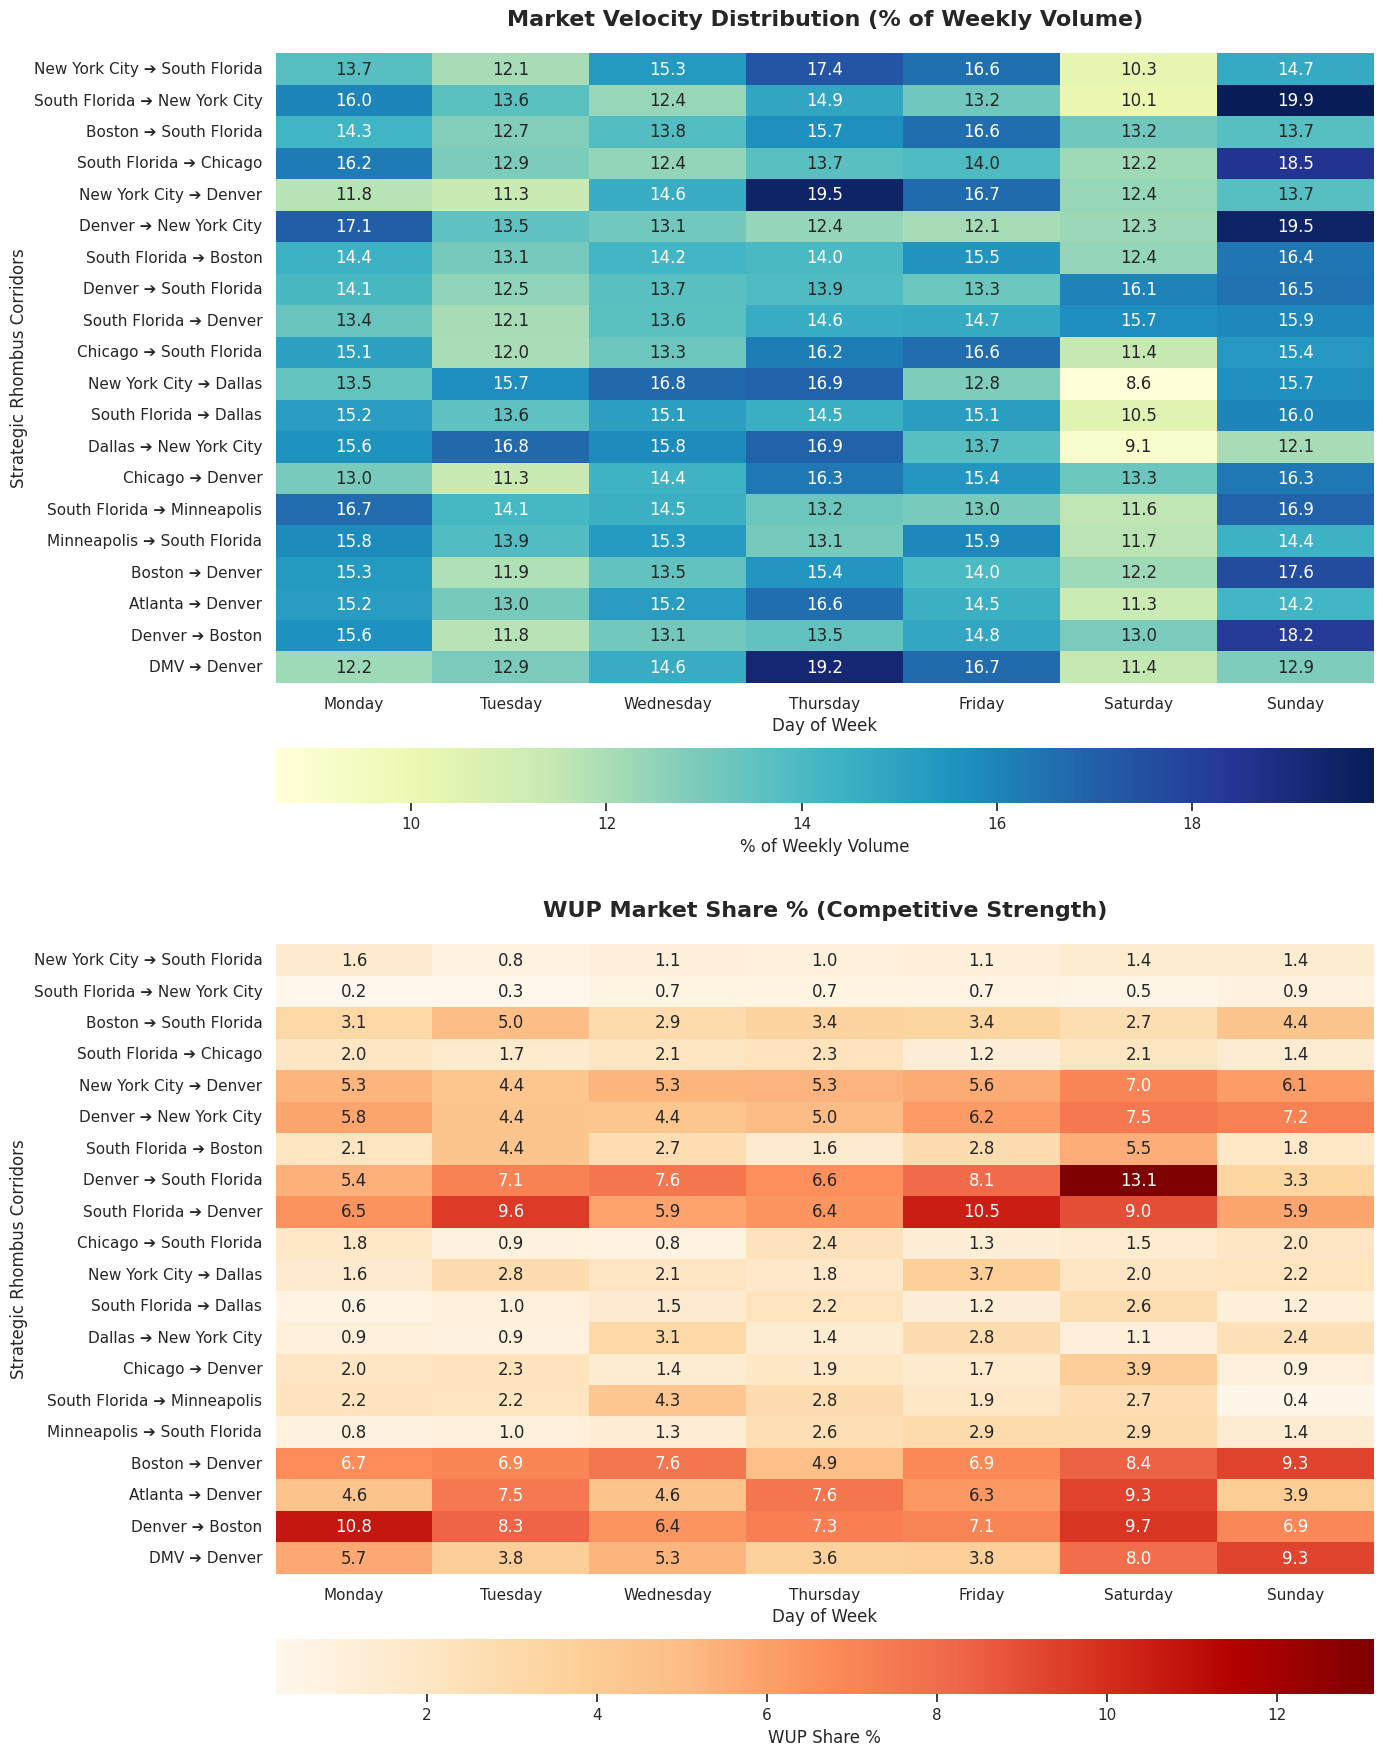

💡 PREMIUM EXTRACTION AUDIT:
Compare the peaks in the top chart (Market Velocity) to the strength in the bottom chart (WUP Share).
High-velocity peaks with high WUP share are your primary 'Premium Toggle' candidates.


In [36]:
# -----------------------------------------------------------------------------------------
# CELL 8: STACKED DOW STRATEGIC HEATMAPS
# -----------------------------------------------------------------------------------------

# 1. Normalize the Market Volume to see % of weekly flow per corridor
dow_market_pct = dow_market.div(dow_market.sum(axis=1), axis=0) * 100

# Create a figure with two vertical subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 18))

# --- 1. MARKET TEMPORAL DISTRIBUTION (% of Weekly Total) ---
sns.heatmap(dow_market_pct, annot=True, fmt=".1f", cmap="YlGnBu", ax=ax1, 
            cbar_kws={'label': '% of Weekly Volume', 'orientation': 'horizontal', 'pad': 0.08})
ax1.set_title("Market Velocity Distribution (% of Weekly Volume)", fontsize=16, fontweight='bold', pad=20)
ax1.set_xlabel("Day of Week", fontsize=12)
ax1.set_ylabel("Strategic Rhombus Corridors", fontsize=12)

# --- 2. WUP SHARE HEATMAP (% Market Share) ---
sns.heatmap(dow_share, annot=True, fmt=".1f", cmap="OrRd", ax=ax2, 
            cbar_kws={'label': 'WUP Share %', 'orientation': 'horizontal', 'pad': 0.08})
ax2.set_title("WUP Market Share % (Competitive Strength)", fontsize=16, fontweight='bold', pad=20)
ax2.set_xlabel("Day of Week", fontsize=12)
ax2.set_ylabel("Strategic Rhombus Corridors", fontsize=12)

plt.tight_layout()
plt.show()

# --- REFINED STRATEGIC SUMMARY ---
print(f"💡 PREMIUM EXTRACTION AUDIT:")
print(f"Compare the peaks in the top chart (Market Velocity) to the strength in the bottom chart (WUP Share).")
print(f"High-velocity peaks with high WUP share are your primary 'Premium Toggle' candidates.")

In [11]:
# -----------------------------------------------------------------------------------------
# CELL 9: PREPARE TOD HEATMAP DATA (RM BUCKETS)
# -----------------------------------------------------------------------------------------

# 1. Define the Revenue Management Time Buckets
def get_rm_bucket(hour):
    if 7 <= hour <= 9:   return '07:00-09:59'
    if 10 <= hour <= 12: return '10:00-12:59'
    if 13 <= hour <= 15: return '13:00-15:59'
    if 16 <= hour <= 18: return '16:00-18:59'
    if 19 <= hour <= 21: return '19:00-21:59'
    return 'Off-Peak (Late/Early)'

# 2. Apply buckets to the heatmap dataframe
df_heatmap['tod_bucket'] = df_heatmap['hour'].apply(get_rm_bucket)

# 3. Ensure logical ordering for the heatmap X-axis
tod_order = ['07:00-09:59', '10:00-12:59', '13:00-15:59', '16:00-18:59', '19:00-21:59', 'Off-Peak (Late/Early)']
df_heatmap['tod_bucket'] = pd.Categorical(df_heatmap['tod_bucket'], categories=tod_order, ordered=True)

# 4. Aggregate Market TOD Volume
tod_market = df_heatmap.groupby(['corridor', 'tod_bucket'], observed=False).size().unstack(fill_value=0)
tod_market_pct = tod_market.div(tod_market.sum(axis=1), axis=0) * 100

# 5. Aggregate WUP TOD Volume for Share %
tod_wup = df_heatmap[df_heatmap['is_wup'] == True].groupby(['corridor', 'tod_bucket'], observed=False).size().unstack(fill_value=0)
tod_share = (tod_wup / tod_market * 100).fillna(0)

# 6. Re-index to maintain Top 20 ranking
tod_market_pct = tod_market_pct.reindex(target_corridors)
tod_share = tod_share.reindex(target_corridors)

print(f"✅ TOD Heatmap Data Ready using RM Buckets")

✅ TOD Heatmap Data Ready using RM Buckets


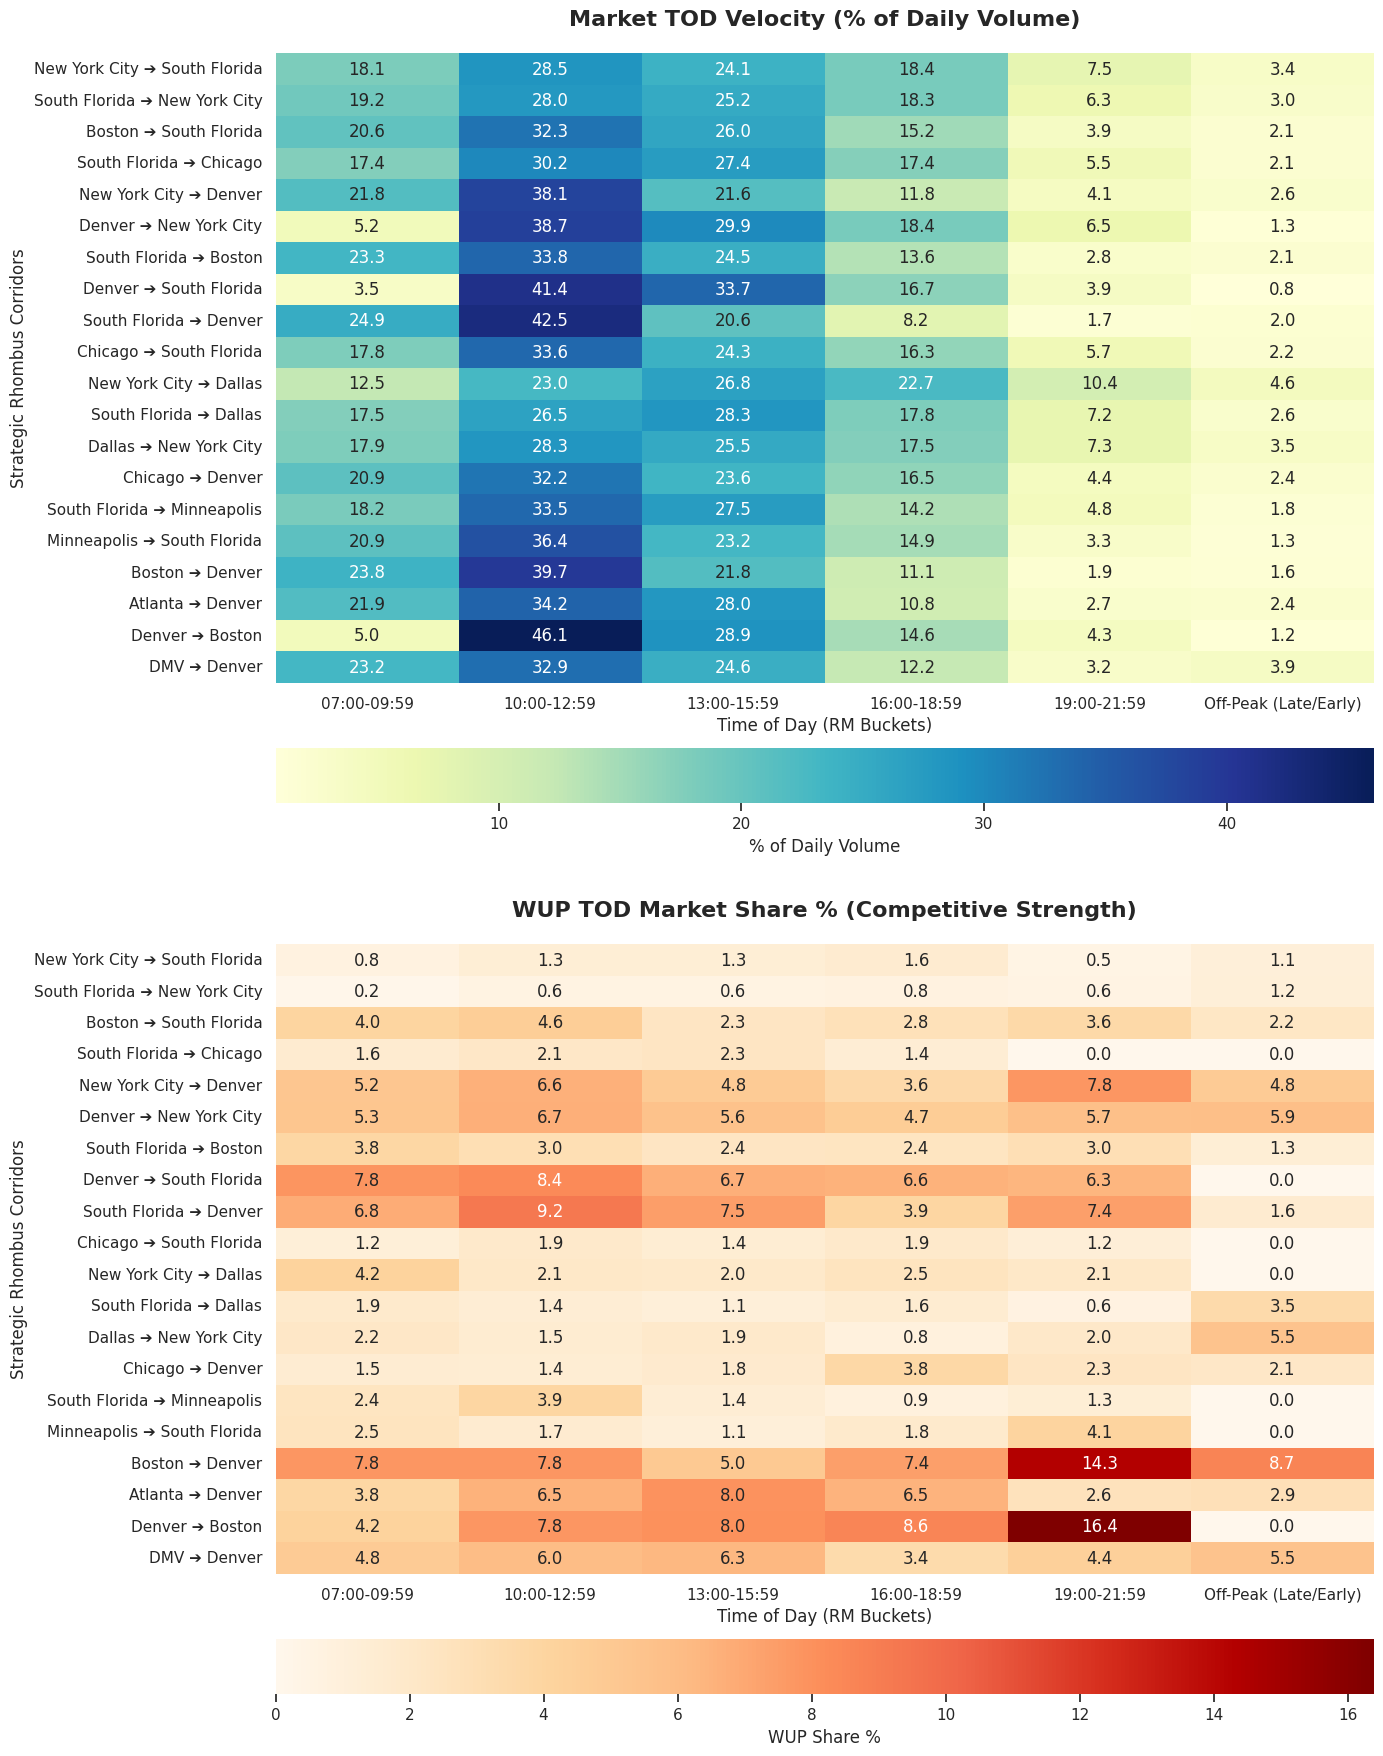

💡 TOD PREMIUM AUDIT:
Identify windows where WUP Share (Bottom) is high during peak Market Velocity (Top).
Example: If 10:00-12:59 is the darkest blue and also dark red, that's your 'Golden Window' for pricing.


In [12]:
# -----------------------------------------------------------------------------------------
# CELL 10: STACKED TOD STRATEGIC HEATMAPS
# -----------------------------------------------------------------------------------------

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 18))

# --- 1. MARKET TOD DISTRIBUTION (% of Daily Total) ---
sns.heatmap(tod_market_pct, annot=True, fmt=".1f", cmap="YlGnBu", ax=ax1, 
            cbar_kws={'label': '% of Daily Volume', 'orientation': 'horizontal', 'pad': 0.08})
ax1.set_title("Market TOD Velocity (% of Daily Volume)", fontsize=16, fontweight='bold', pad=20)
ax1.set_xlabel("Time of Day (RM Buckets)", fontsize=12)
ax1.set_ylabel("Strategic Rhombus Corridors", fontsize=12)

# --- 2. WUP TOD SHARE HEATMAP (% Market Share) ---
sns.heatmap(tod_share, annot=True, fmt=".1f", cmap="OrRd", ax=ax2, 
            cbar_kws={'label': 'WUP Share %', 'orientation': 'horizontal', 'pad': 0.08})
ax2.set_title("WUP TOD Market Share % (Competitive Strength)", fontsize=16, fontweight='bold', pad=20)
ax2.set_xlabel("Time of Day (RM Buckets)", fontsize=12)
ax2.set_ylabel("Strategic Rhombus Corridors", fontsize=12)

plt.tight_layout()
plt.show()

# --- TOD STRATEGIC SUMMARY ---
print(f"💡 TOD PREMIUM AUDIT:")
print(f"Identify windows where WUP Share (Bottom) is high during peak Market Velocity (Top).")
print(f"Example: If 10:00-12:59 is the darkest blue and also dark red, that's your 'Golden Window' for pricing.")

In [37]:
# ============================================
# SMID TOP 20 EXTRACTION (HEATMAP-ALIGNED FINAL)
# ============================================

import pandas as pd

# -----------------------------
# CONFIG — SMID
# -----------------------------
BASE_SHARE = 0.034
HOURLY_RATE = 11000

TOTAL_HOURS_LOW = 2600
TOTAL_HOURS_HIGH = 4420

# -----------------------------
# STEP 1: SAFE COPIES
# -----------------------------
df_base = smid_long_haul.copy()
rhombus = master_rhombus.copy()

# -----------------------------
# STEP 2: CLEAN KEYS
# -----------------------------
df_base['FromMetro_clean'] = df_base['FromMetro'].astype(str).str.strip()
df_base['ToMetro_clean'] = df_base['ToMetro'].astype(str).str.strip()

rhombus['corridor_str'] = rhombus['corridor'].astype(str)

def split_corridor(c):
    for sep in ["->", "➔", "→", "�"]:
        if sep in c:
            parts = c.split(sep)
            if len(parts) == 2:
                return parts[0].strip(), parts[1].strip()
    return None, None

rhombus[['FromMetro_clean', 'ToMetro_clean']] = rhombus['corridor_str'] \
    .apply(lambda x: pd.Series(split_corridor(x)))

rhombus_clean = rhombus.dropna(subset=['FromMetro_clean', 'ToMetro_clean']).copy()

# -----------------------------
# STEP 3: MERGE
# -----------------------------
df_heatmap = df_base.merge(
    rhombus_clean[['FromMetro_clean', 'ToMetro_clean']],
    on=['FromMetro_clean', 'ToMetro_clean'],
    how='inner'
).copy()

print("✅ Heatmap rows:", len(df_heatmap))

# -----------------------------
# STEP 4: TIME FEATURES
# -----------------------------
if 'tod_bucket' not in df_heatmap.columns:
    df_heatmap['hour_local'] = pd.to_datetime(df_heatmap['FlightDate_ET']).dt.hour

    def get_tod_bucket(h):
        if 0 <= h < 6: return "00:00-05:59"
        elif 6 <= h < 9: return "06:00-08:59"
        elif 9 <= h < 12: return "09:00-11:59"
        elif 12 <= h < 15: return "12:00-14:59"
        elif 15 <= h < 18: return "15:00-17:59"
        elif 18 <= h < 22: return "18:00-21:59"
        else: return "22:00-23:59"

    df_heatmap['tod_bucket'] = df_heatmap['hour_local'].apply(get_tod_bucket)

if 'day_name' not in df_heatmap.columns:
    df_heatmap['day_name'] = pd.to_datetime(df_heatmap['FlightDate_ET']).dt.day_name()

# FIX categorical issue
df_heatmap['window'] = (
    df_heatmap['day_name'].astype(str) + " | " +
    df_heatmap['tod_bucket'].astype(str)
)

df_heatmap['corridor_clean'] = (
    df_heatmap['FromMetro_clean'] + " -> " + df_heatmap['ToMetro_clean']
)

# -----------------------------
# STEP 5: AGGREGATION
# -----------------------------
combo_market = df_heatmap.groupby(['corridor_clean', 'window']) \
    .size().reset_index(name='market_missions')

combo_wup = df_heatmap[df_heatmap['is_wup'] == True] \
    .groupby(['corridor_clean', 'window']) \
    .size().reset_index(name='wup_missions')

combo = combo_market.merge(combo_wup, on=['corridor_clean', 'window'], how='left').fillna(0)

# -----------------------------
# STEP 6: METRICS (HEATMAP-ALIGNED)
# -----------------------------
combo['share_pct'] = (combo['wup_missions'] / combo['market_missions']) * 100

# 🔥 TRUE HEATMAP VELOCITY
corridor_weekly_total = combo.groupby('corridor_clean')['market_missions'].transform('sum')
combo['velocity_pct'] = (combo['market_missions'] / corridor_weekly_total) * 100

combo['sli'] = combo['share_pct'] / (BASE_SHARE * 100)
combo['score'] = combo['velocity_pct'] * combo['sli']

# -----------------------------
# STEP 6.5: VOLUME FILTER
# -----------------------------
combo = combo[combo['market_missions'] >= 15].copy()

# -----------------------------
# STEP 7: HOURS
# -----------------------------
combo['hours_low'] = TOTAL_HOURS_LOW * (combo['velocity_pct'] / 100)
combo['hours_high'] = TOTAL_HOURS_HIGH * (combo['velocity_pct'] / 100)

# -----------------------------
# STEP 8: DYNAMIC CATEGORY
# -----------------------------
share_p50 = combo['share_pct'].quantile(0.50)
share_p70 = combo['share_pct'].quantile(0.70)
share_p85 = combo['share_pct'].quantile(0.85)

velocity_p60 = combo['velocity_pct'].quantile(0.60)
velocity_p75 = combo['velocity_pct'].quantile(0.75)

print("Share thresholds:", share_p50, share_p70, share_p85)
print("Velocity thresholds:", velocity_p60, velocity_p75)

def assign_category(row):
    share = row['share_pct']
    demand = row['velocity_pct']

    if share >= share_p85 and demand >= velocity_p75:
        return "Stronghold Extraction", 0.30
    elif share >= share_p70 and demand >= velocity_p60:
        return "Surge Capture", 0.20
    elif share >= share_p50:
        return "Niche Protection", 0.10
    else:
        return "No Action", 0.0

combo[['category', 'toggle']] = combo.apply(
    lambda row: pd.Series(assign_category(row)),
    axis=1
)

# -----------------------------
# STEP 9: VALUE
# -----------------------------
combo['value_low'] = combo['hours_low'] * HOURLY_RATE * combo['toggle']
combo['value_high'] = combo['hours_high'] * HOURLY_RATE * combo['toggle']

# -----------------------------
# STEP 10: FILTER + RANK
# -----------------------------
combo_filtered = combo[combo['toggle'] > 0].copy()

top20 = combo_filtered.sort_values(by='score', ascending=False).head(20)

top20 = top20[['corridor_clean', 'window', 'category',
               'share_pct', 'velocity_pct', 'sli',
               'toggle', 'hours_low', 'hours_high',
               'value_low', 'value_high']]

top20 = top20.sort_values(by='value_low', ascending=False)

# -----------------------------
# STEP 11: OUTPUT
# -----------------------------
display(top20.style.format({
    'share_pct': '{:.1f}%',
    'velocity_pct': '{:.1f}%',
    'sli': '{:.2f}x',
    'toggle': '{:.0%}',
    'hours_low': '{:,.0f}',
    'hours_high': '{:,.0f}',
    'value_low': '${:,.0f}',
    'value_high': '${:,.0f}'
}))

# -----------------------------
# STEP 12: TOTAL
# -----------------------------
total_low = top20['value_low'].sum()
total_high = top20['value_high'].sum()

print("\n💰 TOTAL REVENUE UPSIDE:")
print(f"Low Case (10 tails): ${total_low:,.0f}")
print(f"High Case (17 tails): ${total_high:,.0f}")

print("\n📊 CATEGORY BREAKDOWN:")
print(top20['category'].value_counts())

✅ Heatmap rows: 60440
Share thresholds: 2.631578947368421 4.47228144989339 6.976744186046512
Velocity thresholds: 3.439083498567967 4.131847725162489


,corridor_clean,window,category,share_pct,velocity_pct,sli,toggle,hours_low,hours_high,value_low,value_high
390,Denver -> New York City,Sunday | 12:00-14:59,Stronghold Extraction,8.7%,7.7%,2.56x,30%,201,342,"$663,457","$1,127,877"
809,South Florida -> Denver,Saturday | 09:00-11:59,Stronghold Extraction,13.1%,7.4%,3.85x,30%,192,326,"$632,181","$1,074,708"
432,Denver -> South Florida,Saturday | 12:00-14:59,Stronghold Extraction,15.5%,7.3%,4.55x,30%,190,323,"$627,293","$1,066,398"
62,Boston -> Denver,Sunday | 09:00-11:59,Stronghold Extraction,8.6%,7.2%,2.52x,30%,187,319,"$618,325","$1,051,153"
815,South Florida -> Denver,Sunday | 09:00-11:59,Stronghold Extraction,7.3%,7.1%,2.14x,30%,184,313,"$607,336","$1,032,471"
557,New York City -> Denver,Friday | 09:00-11:59,Stronghold Extraction,8.6%,6.6%,2.54x,30%,172,292,"$566,042","$962,271"
330,Denver -> Boston,Monday | 12:00-14:59,Stronghold Extraction,11.7%,6.6%,3.44x,30%,171,291,"$564,790","$960,143"
796,South Florida -> Denver,Friday | 09:00-11:59,Stronghold Extraction,9.3%,6.6%,2.74x,30%,171,290,"$563,166","$957,382"
56,Boston -> Denver,Saturday | 09:00-11:59,Stronghold Extraction,9.8%,6.3%,2.88x,30%,164,279,"$541,771","$921,010"
418,Denver -> South Florida,Friday | 12:00-14:59,Stronghold Extraction,9.8%,5.9%,2.88x,30%,154,262,"$509,183","$865,612"



💰 TOTAL REVENUE UPSIDE:
Low Case (10 tails): $9,679,982
High Case (17 tails): $16,455,970

📊 CATEGORY BREAKDOWN:
category
Stronghold Extraction    18
Surge Capture             2
Name: count, dtype: int64


In [17]:
print(combo[['share_pct', 'velocity_pct']].describe())

       share_pct  velocity_pct
count        0.0           0.0
mean         NaN           NaN
std          NaN           NaN
min          NaN           NaN
25%          NaN           NaN
50%          NaN           NaN
75%          NaN           NaN
max          NaN           NaN


In [18]:
df_combo = df_heatmap.copy()

In [20]:
df_combo.head(1)

,FlightDate_utc,Operator,FromAirport,FromState,ToAirport,ToState,Hours,aircraft_tailsign,aircraft_model,aircraft_segment,fuel_uplift_usg,FlightDate_ET,year,month,dow,hour,FromMetro,ToMetro,day_name,corridor,is_wup,tod_bucket
25,2024-03-22T00:18:00.000Z,Mike Kilo Aviation LLC,KMKY,FL,KBIV,MI,2.883333,N680MK,Citation Sovereign,Super Midsize Jet,709.3,2024-03-21 20:18:00-04:00,2024,3,Thursday,20,South Florida,Chicago,Thursday,South Florida ➔ Chicago,False,19:00-21:59
